# Employee Attrition Prediction using Machine Learning

### Internship Project - Week 2

**Name:** Tanishka Gandhi

**Objective :** This project is to analyze employee data and build a machine learning model that predicts whether an employee is likely to leave the organization.


## Task 1: Data Loading & Exploration

####  Understanding the Dataset

Before building any machine learning model, it is important to understand the structure of the dataset,
identify the target variable, and examine employee attrition patterns.

In [1]:
#Pandas is used to load, manipulate, and analyze structured datasets.
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Check Dimensions

In [2]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1470
Columns : 35


### Identify Target column

In [3]:
df["Attrition"].unique()

array(['Yes', 'No'], dtype=object)

### Count Employees Who Left vs Stayed

This helps us understand how many employees remained in the organization and how many resigned.

In [4]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

### Calculate Attrition Rate


In [5]:
employees_left = df["Attrition"].value_counts()["Yes"] 
total_employees = len(df) 
attrition_rate = (employees_left / total_employees) * 100 
print("Attrition Rate =", round(attrition_rate,2), "%")

Attrition Rate = 16.12 %


##### Formula Used

##### Attrition Rate = (Employees Left / Total Employees) × 100

##### Observation
##### This means around 16 out of every 100 employees resigned.

### Identify Numeric and Categorical Columns

In [6]:
# Numeric columns 
numeric_columns = df.select_dtypes(include="number").columns 
# Categorical columns 
categorical_columns = df.select_dtypes(include="object").columns 
print("Number of Numeric Columns :", len(numeric_columns)) 
print("Number of Categorical Columns :", len(categorical_columns))

Number of Numeric Columns : 26
Number of Categorical Columns : 9


### Final Observation on Attrition Rate

##### The attrition distribution is imbalanced.

##### Most employees stayed with the company, while a smaller percentage left.

##### This imbalance may affect machine learning model performance.

## Task 2: Data Cleaning & Preprocessing

### Check for Missing Values

### Objective

The first step in preprocessing is to check whether the dataset contains any missing values. 
Missing values can affect the performance of machine learning models, so they should always be identified before further analysis.

In [7]:
# Check missing values in each column
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
# Count total missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


### Check Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Remove Irrelevant Columns
Remove columns that do not contribute to predicting employee attrition.

In [10]:
# Drop unnecessary columns

df = df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)

In [11]:
# Check updated dataset shape
print(df.shape)

(1470, 31)


### Convert the Target Variable Attrition

#### Objective
Convert the target variable Attrition from categorical values (Yes/No) to numerical values (1/0) because machine learning algorithms work with numerical data.

In [12]:
# Convert target variable into numerical format
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [13]:
# Check first few values
df["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

### Identify Categorical Features
Identify all remaining categorical columns that need to be encoded.

In [14]:
# Find categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [15]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

In [16]:
# Display first five rows
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0


In [17]:
print("Original Shape :", df.shape)
print("Encoded Shape :", df_encoded.shape)

Original Shape : (1470, 31)
Encoded Shape : (1470, 45)


#### Observation for map()
The Attrition column contains only two categories (Yes and No), so it was converted directly into 1 and 0 using the map() function. This makes the target variable suitable for machine learning models.

#### Observation for One-Hot Encoding

The remaining categorical columns contain multiple categories, so One-Hot Encoding was used to create separate binary (0/1) columns for each category. 
This prevents the model from assuming any numerical order or priority between categories.

### Separate Features and Target Variable

In [18]:
# Independent variables
X = df_encoded.drop("Attrition", axis=1)

# Dependent variable
y = df_encoded["Attrition"]

In [19]:
print("Features Shape :", X.shape)   #2D
print("Target Shape :", y.shape)     #1D

Features Shape : (1470, 44)
Target Shape : (1470,)


### Feature Scaling using StandardScaler
Scale the feature values so that all numerical features are on a similar scale.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
print("Final Feature Matrix Shape :", X_scaled.shape)
print("Final Target Shape :", y.shape)

Final Feature Matrix Shape : (1470, 44)
Final Target Shape : (1470,)


## Task 3: Exploratory Data Analysis (EDA)

#### Objective

The objective of Exploratory Data Analysis (EDA) is to understand the relationship between employee attributes and attrition. By analyzing different factors, we can identify patterns that help HR teams understand why employees leave the organization.

### Attrition Rate by Department
Analyze which department has the highest employee attrition rate.

In [22]:
# Calculate attrition percentage department-wise
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


#### Observation

The department Sales has the highest attrition rate , as employees in that department are leaving more frequently than others.

### Attrition by Job Role
Identify which job roles experience the highest employee attrition.

In [23]:
# Calculate attrition percentage by job role
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

jobrole_attrition

Attrition,0,1
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


#### Observation

Job role Sales representative has the highest exit rate ,it should be prioritized for employee retention programs and workplace improvement initiatives.

### Attrition vs Monthly Income
Compare the monthly income of employees who stayed with those who left the company.

In [24]:
# Compare average monthly income
df.groupby("Attrition")["MonthlyIncome"].mean()

Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64

#### Observation
Yes, Employees who left the company generally have a lower average monthly income compared to employees who stayed.

### Attrition vs Work-Life Balance

In [25]:
# Attrition rate by work-life balance
worklife_attrition = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

worklife_attrition

Attrition,0,1
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


#### Observation 
Although WorkLifeBalance is stored as numerical values (1–4), these values represent rating categories rather than continuous 
measurements. Therefore, it is treated as a categorical feature to analyze the attrition rate across different work-life balance levels.

Employees with lower work-life balance ratings tend to show a higher attrition rate.

### Attrition vs Years at Company

In [26]:
years = df.groupby("Attrition")["YearsAtCompany"].mean().round(2)

print(years)

Attrition
0    7.37
1    5.13
Name: YearsAtCompany, dtype: float64


#### Observation

Employees who leave the company generally have fewer years of service, suggesting that attrition is higher during the early stages of employment.

### Business Insight Summary

1. Business Insight 1: The Sales department has the highest attrition rate (20.63%), suggesting that employees in this department are more 
likely to leave the company than employees in other departments.

2. Business Insight 2: Sales Representatives have the highest attrition rate (39.76%) among all job roles. This indicates that
employees in this role are at the greatest risk of leaving the company, and the HR team should investigate the reasons behind this high turnover.

3. Business Insight 3: Employees who left the company had a lower average monthly income (₹4,787) compared to employees who stayed (₹6,833), 
indicating that compensation may influence employee retention.

4. Business Insight 4: Employees with a Work-Life Balance rating of 1 showed the highest attrition rate, 
suggesting that improving work-life balance could help reduce employee turnover.

5. Business Insight 5: Employees who left the organization had an average tenure of 5.13 years, compared to 7.37 years for employees who stayed,  indicating that attrition is more common during the early years of employment.


## Task 4: Model Building & Comparison

### Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)

In [28]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (1176, 44)
Testing Features : (294, 44)
Training Target : (1176,)
Testing Target : (294,)


### Observation

The dataset has been divided into **80% training data** and **20% testing data**. The `stratify=y` parameter 
ensures that the proportion of employees who stayed and left remains similar in both datasets.

### Build Logistic Regression Model
Why Logistic Regression?

Logistic Regression was selected as the baseline model because it is simple, interpretable, and suitable for binary classification.

In [29]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### Build Random Forest Model
Why Random Forest?

Random Forest was selected because it can capture complex relationships while reducing overfitting.

In [30]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Build Gradient Boosting Model
Why Gradient Boosting?

Gradient Boosting was selected because it improves performance by sequentially correcting the errors made by previous trees.

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

### Make Predictions

In [32]:
# Predict using Logistic Regression
lr_pred = lr_model.predict(X_test)

In [33]:
# Predict using Random Forest
rf_pred = rf_model.predict(X_test)

In [34]:
# Predict using Gradient Boosting
gb_pred = gb_model.predict(X_test)

In [35]:
# Prediction probabilities

lr_prob = lr_model.predict_proba(X_test)[:, 1]

rf_prob = rf_model.predict_proba(X_test)[:, 1]

gb_prob = gb_model.predict_proba(X_test)[:, 1]

### Comparison table for all 3 models

In [36]:
# Summary of trained models

models = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Status": [
        "Trained",
        "Trained",
        "Trained"
    ]
})

models

,Model,Status
0,Logistic Regression,Trained
1,Random Forest,Trained
2,Gradient Boosting,Trained


**Observation:** The table confirms that all three machine learning models have been successfully trained. 
Their performance will be evaluated and compared in the 
next task using metrics such as Precision, Recall, F1-Score, and ROC-AUC.

## Task 5: Model Evaluation

### Import Evaluation Metrics
Import the evaluation metrics required to measure and compare the performance of the machine learning models.

In [37]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

### Evaluate Logistic Regression
Evaluate the performance of the Logistic Regression model using different classification metrics.

In [38]:
# Logistic Regression Evaluation

lr_precision = precision_score(y_test, lr_pred)

lr_recall = recall_score(y_test, lr_pred)

lr_f1 = f1_score(y_test, lr_pred)

lr_auc = roc_auc_score(y_test, lr_pred)

In [39]:
print("Precision :", round(lr_precision,3))
print("Recall :", round(lr_recall,3))
print("F1 Score :", round(lr_f1,3))
print("ROC-AUC :", round(lr_auc,3))

Precision : 0.341
Recall : 0.617
F1 Score : 0.439
ROC-AUC : 0.695


#### Observation

The above metrics indicate how well the Logistic Regression model identifies employees who are likely to leave the company.

### Evaluate Random Forest

In [40]:
# Random Forest Evaluation

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_auc = roc_auc_score(y_test, rf_pred)

In [41]:
print("Precision :", round(rf_precision,3))
print("Recall :", round(rf_recall,3))
print("F1 Score :", round(rf_f1,3))
print("ROC-AUC :", round(rf_auc,3))

Precision : 0.375
Recall : 0.064
F1 Score : 0.109
ROC-AUC : 0.522


#### Observation

The Random Forest model is evaluated using the same metrics, making it easy to compare its performance with the other models.

### Evaluate Gradient Boosting

In [42]:
# Gradient Boosting Evaluation

gb_precision = precision_score(y_test, gb_pred)

gb_recall = recall_score(y_test, gb_pred)

gb_f1 = f1_score(y_test, gb_pred)

gb_auc = roc_auc_score(y_test, gb_pred)

In [43]:
print("Precision :", round(gb_precision,3))
print("Recall :", round(gb_recall,3))
print("F1 Score :", round(gb_f1,3))
print("ROC-AUC :", round(gb_auc,3))

Precision : 0.588
Recall : 0.213
F1 Score : 0.312
ROC-AUC : 0.592


#### Observation

The Gradient Boosting model has been evaluated using the same performance metrics for a fair comparison.

### Comparison Table

In [44]:
# Create comparison table

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision":[
        round(lr_precision,3),
        round(rf_precision,3),
        round(gb_precision,3)
    ],

    "Recall":[
        round(lr_recall,3),
        round(rf_recall,3),
        round(gb_recall,3)
    ],

    "F1 Score":[
        round(lr_f1,3),
        round(rf_f1,3),
        round(gb_f1,3)
    ],

    "ROC-AUC":[
        round(lr_auc,3),
        round(rf_auc,3),
        round(gb_auc,3)
    ]

})

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341,0.617,0.439,0.695
1,Random Forest,0.375,0.064,0.109,0.522
2,Gradient Boosting,0.588,0.213,0.312,0.592


#### Observation

The comparison table summarizes the performance of all three models using common evaluation metrics, making it easier to identify
the most effective model for predicting employee attrition.

### Confusion Matrix

In [45]:
# Logistic Regression
lr_cm = confusion_matrix(y_test, lr_pred)
print("Logistic Regression")
print(lr_cm)

Logistic Regression
[[191  56]
 [ 18  29]]


In [46]:
# Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)
print("Random Forest")
print(rf_cm)

Random Forest
[[242   5]
 [ 44   3]]


In [47]:
# Gradient Boosting
gb_cm = confusion_matrix(y_test, gb_pred)
print("Gradient Boosting")
print(gb_cm)

Gradient Boosting
[[240   7]
 [ 37  10]]


### Best Model

Among the three models, **Logistic Regression** was selected as the best-performing model. It achieved the highest Recall (0.617), F1-Score (0.439), and ROC-AUC Score (0.695). Since the primary objective of employee attrition prediction is to identify employees who are likely to leave, a higher Recall is more valuable. Therefore, Logistic Regression was chosen as the final model.

### Coefficients (Logistic Regression)

#### Objective

Since Logistic Regression does not provide `feature_importances_`, the absolute values of its coefficients
(`coef_`) are used to rank the features based on their influence.

In [48]:
# Create Coefficient DataFrame
coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": abs(lr_model.coef_[0])
})

# Sort features based on coefficient values
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

# Display Top 10 Most Influential Features
coefficient_df.head(10)

,Feature,Coefficient
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


In [49]:
abs(lr_model.coef_[0])

array([0.26733112, 0.23278015, 0.32217791, 0.02021542, 0.43572982,
       0.05597003, 0.28805012, 0.65918912, 0.39084982, 0.10037853,
       0.02717084, 0.4669579 , 0.23982598, 0.14321661, 0.25129427,
       0.20369986, 0.65693108, 0.17413166, 0.22532809, 0.25995386,
       0.22914382, 0.50038947, 0.46366798, 0.71933467, 0.5116494 ,
       0.35856876, 0.48169025, 0.50650539, 0.24762423, 0.44758318,
       0.39708129, 0.11921502, 0.15351237, 0.38200532, 0.79787398,
       0.00186704, 0.11444919, 0.38868913, 0.31074081, 0.37050836,
       0.55251524, 0.19302762, 0.45616761, 0.7664122 ])

### Observation

The table ranks the top 10 features that have the strongest influence on predicting employee attrition. Features with higher importance values
have a greater impact on the model's prediction and can help HR identify key factors affecting employee retention.

## Task 6: Data Visualization

### Chart 1: Attrition Rate by Department and Job Role

Chart 1A: Department-wise Attrition

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

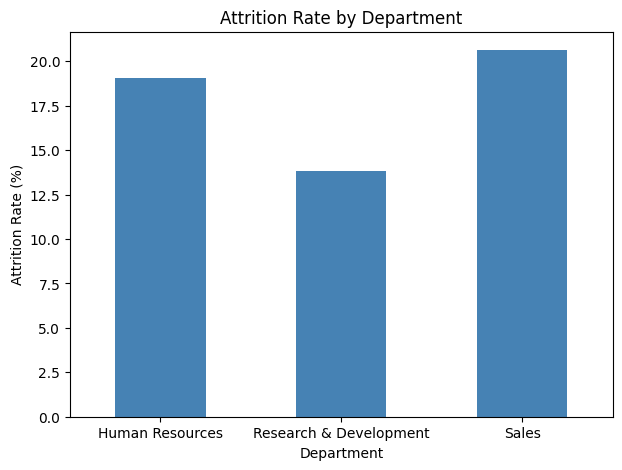

In [51]:
# Department-wise attrition rate

department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition[1].plot(
    kind="bar",
    figsize=(7,5),
    color="steelblue"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.savefig("charts/bar_department.png")
plt.show()

Chart 1B: Job Role-wise Attrition

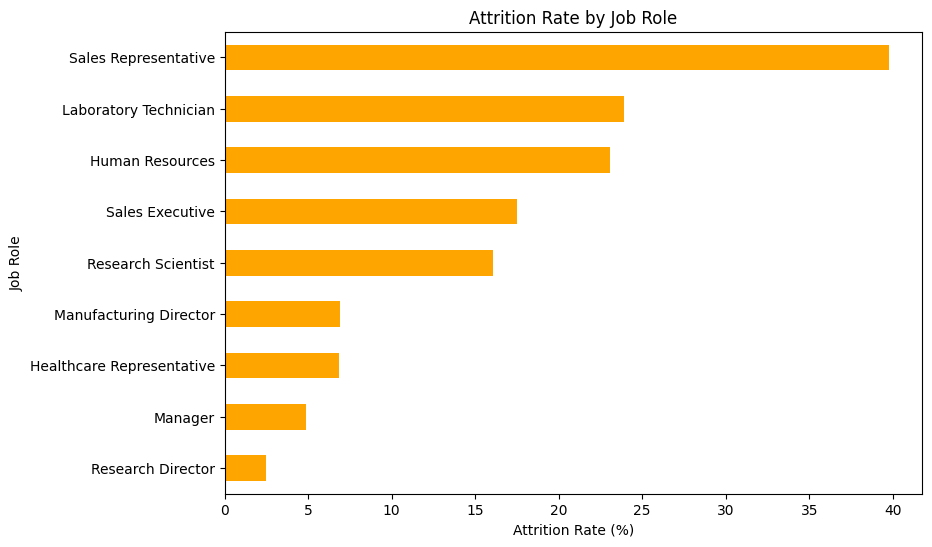

In [52]:
# Job Role-wise attrition rate

jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

jobrole_attrition[1].sort_values().plot(
    kind="barh",
    figsize=(9,6),
    color="orange"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.savefig("charts/barh_jobrole.png")
plt.show()

## Chart 2: Monthly Income vs Attrition

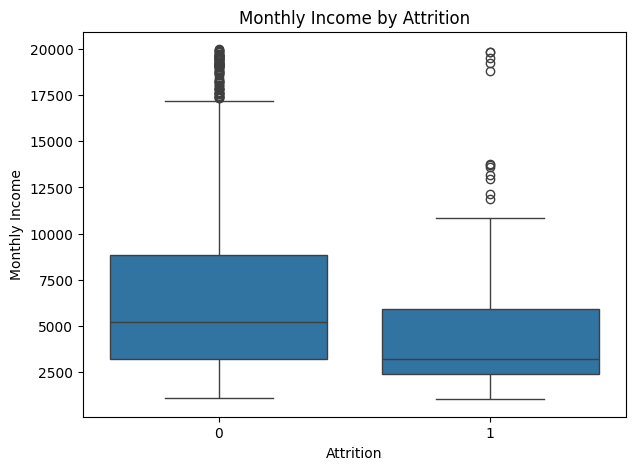

In [53]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.savefig("charts/boxplot_income.png")
plt.show()

### Observation

The box plot compares the salary distribution of employees who stayed and those who left, helping 
identify whether income is associated with employee attrition.

### Chart 3: Confusion Matrix Heatmap

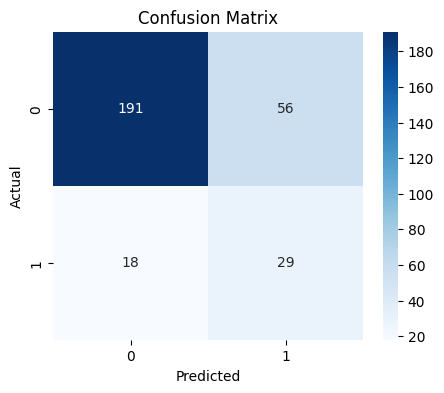

In [54]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("charts/confusion_heatmap.png")
plt.show()

### Chart 4: Top 10 Feature Coefficient

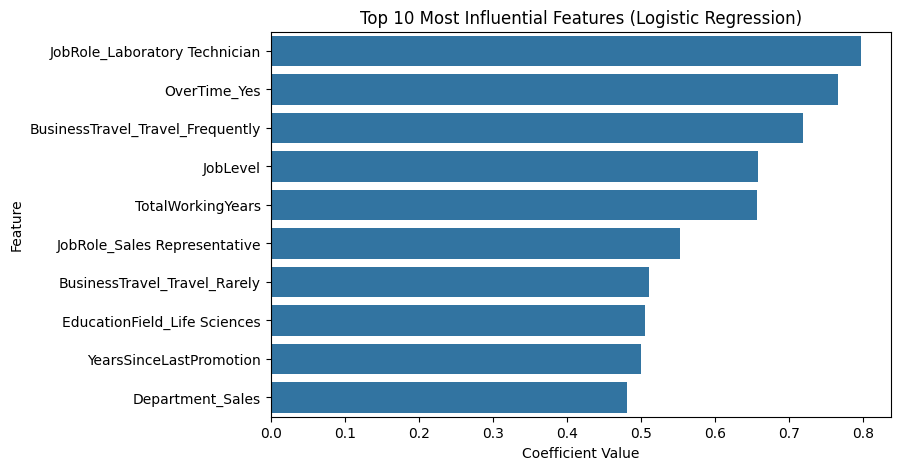

In [55]:
# Select Top 10 Features
top10 = coefficient_df.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Most Influential Features (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.savefig("charts/barplot_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

## Task 7: HR Insights & Business Recommendations

### 1. Which 3 Factors Most Strongly Predict Employee Attrition?

Based on the model analysis, the three strongest factors associated with employee attrition are:

- Employees working as Laboratory Technicians.
- Employees who frequently work overtime.
- Employees who travel frequently for business.

These factors have the greatest influence on predicting whether an employee is likely to leave the organization.

### 2. Which department or job role should HR prioritize for retention efforts?

Based on the EDA results, the **Sales department** has the highest attrition rate (**20.63%**) among alldepartments. Among job roles, 
**Sales Representatives** show the highest attrition rate (**39.76%**).
Therefore, HR should prioritize retention efforts for employees in the Sales department, especially those working as Sales Representatives, by
identifying the reasons for turnover and implementing targeted retention strategies.

### 3. Does salary alone explain attrition or are there other stronger factors?

No. Salary influences employee attrition, but it is not the only factor. The analysis shows that overtime, business travel frequency,
and job role have an even stronger influence on employee attrition. This indicates that improving work conditions and employee well-being 
is as important as offering competitive salaries.

### 4. HR Recommendations
##### Recommendation 1:

HR should focus more on employees working in the Sales department, especially Sales Representatives, as they have the highest attrition rate. Regular one-on-one discussions, career growth opportunities, and timely recognition can help improve employee retention.

##### Recommendation 2:

The company should reduce excessive overtime and review business travel requirements. Providing better work-life balance through flexible work options, wellness programs, and proper workload management can help reduce employee turnover.

### 5. Limitation of the Model
The model predicts employee attrition based on historical employee data. However, it cannot capture personal reasons 
such as family responsibilities, job satisfaction, relationships with managers, or better opportunities outside the company.
Therefore, HR should use this model as a support tool along with employee feedback and professional judgment when making retention decisions.